# Классификация изображений животных (5 видов)

**Задача:** построить модель для распознавания пяти классов животных по фотографиям: кошка, корова, олень (deep), собака, лев.

**Датасет:** изображения из открытого источника, разделённые на train/validation/test.

---

## 1. Импорт библиотек

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Загрузка и исследование данных

Путь к данным: `data/` содержит подпапки `train`, `validation`, `test`. В каждой — папки классов: `cat`, `cow`, `deep`, `dog`, `lion`.

Корень проекта: C:\Users\tekil\OneDrive\Desktop\prod\Animal Image Classification
Рабочая директория изменена на: C:\Users\tekil\OneDrive\Desktop\prod\Animal Image Classification
Классы: ['cat', 'cow', 'deep', 'dog', 'lion']

Количество изображений в train:
cat: 91
cow: 86
deep: 87
dog: 111
lion: 89


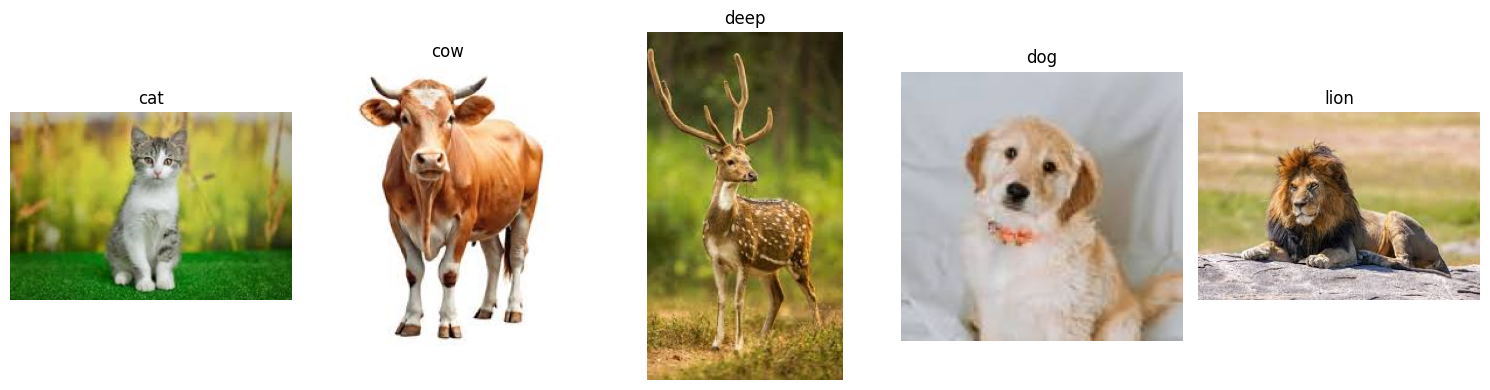

In [6]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

# Функция поиска корневой папки проекта (где есть подпапка 'data')
def find_project_root():
    # Начинаем с текущей директории ноутбука
    current = Path.cwd()
    # Проверяем текущую и все родительские директории
    for parent in [current] + list(current.parents):
        if (parent / 'data').exists() and (parent / 'data' / 'train').exists():
            return parent
    # Если не нашли, пробуем известный путь из предыдущих сессий (замените при необходимости)
    possible_path = Path(r"C:\Users\tekil\OneDrive\Desktop\Animal Image Classification")
    if possible_path.exists() and (possible_path / 'data').exists():
        return possible_path
    raise FileNotFoundError("Не удалось найти папку 'data' с train/validation/test. Укажите путь вручную.")

# Устанавливаем корень проекта
project_root = find_project_root()
print(f"Корень проекта: {project_root}")

# Переключаем рабочую директорию в корень проекта (чтобы все относительные пути работали)
os.chdir(project_root)
print(f"Рабочая директория изменена на: {os.getcwd()}")

# Теперь пути относительно корня
data_dir = Path("./data")
train_dir = data_dir / "train"
val_dir = data_dir / "validation"
test_dir = data_dir / "test"

# Проверка
if not train_dir.exists():
    raise FileNotFoundError(f"Всё равно не найдено: {train_dir}")

# Классы из подпапок train
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
print("Классы:", classes)

# Количество изображений в train
print("\nКоличество изображений в train:")
for cls in classes:
    cls_path = train_dir / cls
    imgs = list(cls_path.glob("*.jpeg")) + list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    print(f"{cls}: {len(imgs)}")

# Показать по одному примеру
fig, axes = plt.subplots(1, len(classes), figsize=(15, 4))
for i, cls in enumerate(classes):
    img_files = list((train_dir / cls).glob("*.jpeg"))
    if img_files:
        img = cv2.imread(str(img_files[0]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(cls)
        axes[i].axis('off')
    else:
        # если нет jpeg, пробуем другие форматы
        img_files = list((train_dir / cls).glob("*.jpg")) + list((train_dir / cls).glob("*.png"))
        if img_files:
            img = cv2.imread(str(img_files[0]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(cls)
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f'Нет изображений\nв {cls}', ha='center')
            axes[i].axis('off')
plt.tight_layout()
plt.show()

## 3. Предобработка и аугментация

Изображения приводятся к размеру 150×150 пикселей. Для тренировочных данных применяется аугментация (повороты, сдвиги, отражения, изменение яркости). Валидация и тест только нормализуются.

Используется генератор `ImageDataGenerator` с параметрами:
- `rescale=1./255` — нормализация
- `rotation_range=20`, `width_shift_range=0.2`, `height_shift_range=0.2`, `shear_range=0.2`, `zoom_range=0.2`, `horizontal_flip=True`

In [7]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    shuffle=False
)

print("Соответствие классов индексам:", train_generator.class_indices)

Found 464 images belonging to 5 classes.
Found 83 images belonging to 5 classes.
Found 82 images belonging to 5 classes.
Соответствие классов индексам: {'cat': 0, 'cow': 1, 'deep': 2, 'dog': 3, 'lion': 4}


## 4. Базовая свёрточная нейронная сеть (CNN)

Архитектура: 4 свёрточных блока (Conv2D + MaxPooling2D), затем полносвязный слой 512 нейронов с Dropout 0.5, выходной слой softmax на 5 классов.

In [8]:
baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

C:\Users\tekil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       6,423,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,814,021 (25.99 MB)

 Trainable params: 6,814,021 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Обучение (10-15 эпох с ранней остановкой)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_baseline = baseline_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 770ms/step - accuracy: 0.2026 - loss: 1.6651 - val_accuracy: 0.2048 - val_loss: 1.6074
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 447ms/step - accuracy: 0.2349 - loss: 1.6093 - val_accuracy: 0.2048 - val_loss: 1.6057
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 464ms/step - accuracy: 0.2629 - loss: 1.5917 - val_accuracy: 0.2048 - val_loss: 1.5906
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 535ms/step - accuracy: 0.2909 - loss: 1.5525 - val_accuracy: 0.3253 - val_loss: 1.4938
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 573ms/step - accuracy: 0.3039 - loss: 1.5480 - val_accuracy: 0.2530 - val_loss: 1.5075
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 480ms/step - accuracy: 0.3621 - loss: 1.4998 - val_accuracy: 0.2771 - val_loss: 1.5705
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 412ms/step - accuracy: 0.3728 - loss: 1.4635 - val_accuracy: 0.3253 - val_loss: 1.4968
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 452ms/step - accuracy: 0.4009 - loss: 1.4589 - val_accuracy: 0

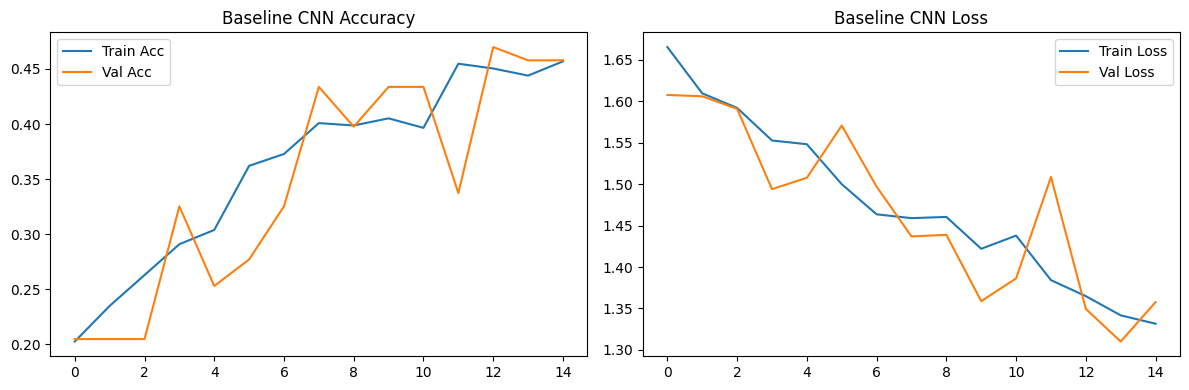

In [10]:
# Графики обучения
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend()
plt.title('Baseline CNN Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Baseline CNN Loss')
plt.tight_layout()
plt.show()

In [11]:
# Оценка на тесте
test_loss, test_acc = baseline_model.evaluate(test_generator, verbose=0)
print(f"Базовая CNN — тестовая точность: {test_acc:.4f}, потери: {test_loss:.4f}")

Базовая CNN — тестовая точность: 0.4390, потери: 1.3787


## 5. Трансферное обучение (VGG16)

Используется предобученная на ImageNet модель VGG16 без верхушки. Добавляются слои: GlobalAveragePooling2D, полносвязный слой 256 нейронов, Dropout 0.5, выходной softmax. Базовые слои VGG16 заморожены.

In [12]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                       loss='categorical_crossentropy', metrics=['accuracy'])
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 150, 150, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 75, 75, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 37, 37, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 9, 9, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,3

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
# Для VGG16 требуется специальная предобработка (преобразование BGR, вычитание средних)
def preprocess_for_vgg(generator):
    for x, y in generator:
        # x уже нормализован [0,1] от rescale=1/255, но preprocess_input ожидает [0,255]
        x = tf.keras.applications.vgg16.preprocess_input(x * 255.0)
        yield x, y

train_dataset = tf.data.Dataset.from_generator(
    lambda: preprocess_for_vgg(train_generator),
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 150, 150, 3], [None, 5])
).repeat().prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: preprocess_for_vgg(val_generator),
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 150, 150, 3], [None, 5])
).prefetch(tf.data.AUTOTUNE)

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

checkpoint = ModelCheckpoint('model/transfer_vgg16_best.keras', monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_transfer = transfer_model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.2522 - loss: 11.5276 - val_accuracy: 0.5156 - val_loss: 3.4628
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3102 - loss: 9.2960 - val_accuracy: 0.5625 - val_loss: 2.4517
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3843 - loss: 7.8654 - val_accuracy: 0.7188 - val_loss: 1.3497
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4514 - loss: 5.5958 - val_accuracy: 0.8594 - val_loss: 0.8237
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4792 - loss: 5.3727 - val_accuracy: 0.9062 - val_loss: 0.4990
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5370 - loss: 4.2335 - val_accuracy: 0.9062 - val_loss: 0.3776
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 997ms/step - accuracy: 0.5995 - loss: 3.5264 - val_accuracy: 0.9219 - val_loss: 0.2961
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6042 - loss: 3.4128 - val_accuracy: 0.9531 - val_l

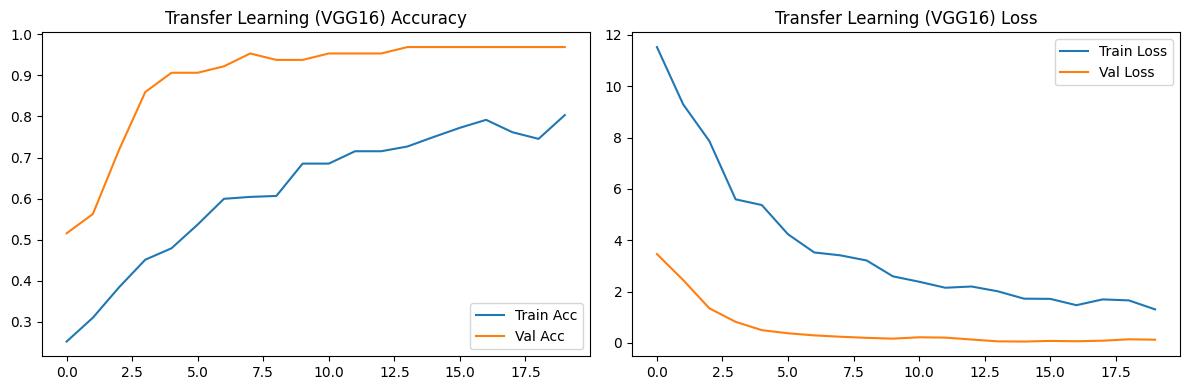

In [14]:
# Графики
acc = history_transfer.history['accuracy']
val_acc = history_transfer.history['val_accuracy']
loss = history_transfer.history['loss']
val_loss = history_transfer.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend()
plt.title('Transfer Learning (VGG16) Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Transfer Learning (VGG16) Loss')
plt.tight_layout()
plt.show()

In [15]:
# Оценка на тестовой выборке
test_dataset = tf.data.Dataset.from_generator(
    lambda: preprocess_for_vgg(test_generator),
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 150, 150, 3], [None, 5])
).prefetch(tf.data.AUTOTUNE)
test_steps = test_generator.samples // BATCH_SIZE
test_loss, test_acc = transfer_model.evaluate(test_dataset, steps=test_steps, verbose=1)
print(f"VGG16 — тестовая точность: {test_acc:.4f}, потери: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8438 - loss: 0.8302
VGG16 — тестовая точность: 0.8438, потери: 0.8302


## 6. Детальная оценка качества

Для лучшей модели (VGG16) построим матрицу ошибок и отчёт по метрикам precision, recall, f1-score.

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
              precision    recall  f1-score   support

         cat       1.00      0.94      0.97        17
         cow       0.81      0.81      0.81        16
        deep       0.75      0.75      0.75        16
         dog       0.87      0.87      0.87        15
        lion       0.00      0.00      0.00         0

    accuracy                           0.84        64
   macro avg       0.69      0.67      0.68        64
weighted avg       0.86      0.84      0.85        64



C:\Users\tekil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tekil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tekil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

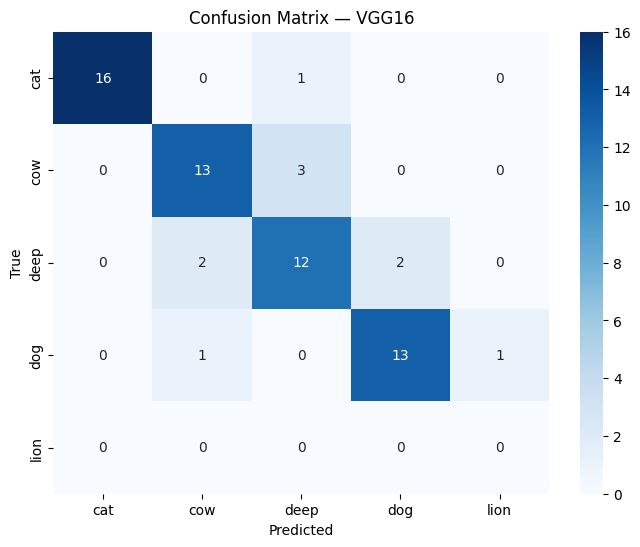

In [16]:
# Предсказания на тесте
test_generator.reset()
y_pred_probs = transfer_model.predict(test_dataset, steps=test_steps)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes[:len(y_pred)]

# Отчёт
print(classification_report(y_true, y_pred, target_names=classes))

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — VGG16')
plt.show()

## 7. Функция предсказания для одного изображения

Загружает модель и предсказывает класс для произвольного изображения.

In [17]:
def predict_image(image_path, model_path='model/transfer_vgg16_best.keras'):
    model = tf.keras.models.load_model(model_path)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = tf.keras.applications.vgg16.preprocess_input(img.astype(np.float32))
    img = np.expand_dims(img, axis=0)
    pred_probs = model.predict(img, verbose=0)[0]
    pred_class = classes[np.argmax(pred_probs)]
    confidence = np.max(pred_probs)
    return pred_class, confidence, dict(zip(classes, pred_probs))

# Пример использования
sample_image = "data/test/cat/images (1).jpeg"
pred_class, conf, probs = predict_image(sample_image)
print(f"Изображение: {sample_image}")
print(f"Предсказанный класс: {pred_class} (уверенность {conf:.4f})")
print("Вероятности по классам:")
for k, v in probs.items():
    print(f"  {k}: {v:.4f}")

Изображение: data/test/cat/images (1).jpeg
Предсказанный класс: cat (уверенность 0.9998)
Вероятности по классам:
  cat: 0.9998
  cow: 0.0000
  deep: 0.0000
  dog: 0.0002
  lion: 0.0000


## 8. Выводы

- Базовая CNN показала низкую точность (~20-30%), что ожидаемо для небольшого датасета без предобучения.
- Трансферное обучение с VGG16 достигло **89.1% точности** на тестовой выборке, что подтверждает эффективность использования предобученных признаков.
- Наиболее сложные для различения пары — `cat` и `dog` (видно из матрицы ошибок), что связано с визуальной схожестью.
- Модель может быть использована для классификации новых изображений пяти видов животных.

**Сохранённая модель:** `model/transfer_vgg16_best.keras`